In [1]:
# config.py

# MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
MODEL_NAME = "universalml/Nepali_Embedding_Model"

CHROMA_DB_PATH = "./chroma_db_nepali_nepali_embedding_model"
COLLECTION_NAME = "company_act_nepali"

CORPUS_CSV_PATH = "company_ne.csv"
QUERIES_JSON_PATH = "eval_queries_ne.json"
EVALUATION_SAVING_DIR ="nepali_embedding_model/"

TOP_K_RETRIEVAL = 3

In [2]:
import pandas as pd
import json
import chromadb
from chromadb.utils import embedding_functions
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Any, Optional
from tqdm import tqdm
import matplotlib.pyplot as plt
import time
import torch
import os



In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
def load_nepali_corpus(file_path):
    """Reads the CSV, drops nulls, and formats context."""
    print(f"Loading corpus from {file_path}...")
    df = pd.read_csv(file_path)
    df = df.dropna(subset=['text', 'id', 'section'])
    
    doc_ids = df['id'].tolist()
    # Combine section and text
    doc_texts = (df['section'] + " \n " + df['text']).tolist()
    
    return doc_ids, doc_texts

def load_evaluation_queries(file_path):
    """Loads the ground truth JSON."""
    print(f"Loading queries from {file_path}...")
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

In [5]:
# vector_store.py
import chromadb
from chromadb.utils import embedding_functions

class ChromaManager:
    def __init__(self, db_path, collection_name, model_name):
        self.client = chromadb.PersistentClient(path=db_path)
        self.collection_name = collection_name
        self.embedding_fn = embedding_functions.SentenceTransformerEmbeddingFunction(model_name=model_name)
        
        # FIX: Look for the existing collection locally. 
        # If it's already there, load it. If not, create it.
        self.collection = self.client.get_or_create_collection(
            name=self.collection_name, 
            embedding_function=self.embedding_fn
        )

    def wipe_and_reset(self):
        """Call this explicitly ONLY when you change your CSV data or want a clean start."""
        print(f"Wiping existing collection: {self.collection_name}...")
        try:
            self.client.delete_collection(name=self.collection_name)
        except Exception:
            pass
        self.collection = self.client.create_collection(
            name=self.collection_name, 
            embedding_function=self.embedding_fn
        )

    def ingest_documents(self, doc_ids, doc_texts, batch_size=100):
        """Embeds and saves documents to disk with a granular document-level progress bar."""
        total_docs = len(doc_texts)
        print(f"Ingesting {total_docs} documents into ChromaDB...")
        
        # Initialize tqdm with the total number of items, not batches
        with tqdm(total=total_docs, desc="Ingesting", unit="doc") as pbar:
            for i in range(0, total_docs, batch_size):
                batch_end = min(i + batch_size, total_docs)
                batch_ids = doc_ids[i:batch_end]
                batch_texts = doc_texts[i:batch_end]
                
                self.collection.add(
                    documents=batch_texts,
                    ids=batch_ids
                )
                
                # Update progress bar by the actual size of the batch processed
                pbar.update(len(batch_texts))
        
        print("Ingestion complete.")

    def search(self, query_text, k=3):
        """Returns top-K document IDs."""
        results = self.collection.query(
            query_texts=[query_text],
            n_results=k
        )
        return results['ids'][0]

In [6]:
# main_eval.py

def load_data():
    print("="*50)
    print(f"STARTING EVALUATION: {MODEL_NAME}")
    print("="*50)

    # 1. Load Data
    doc_ids, doc_texts = load_nepali_corpus(CORPUS_CSV_PATH)
    eval_data = load_evaluation_queries(QUERIES_JSON_PATH)

    # 2. Initialize Vector Database
    db_manager = ChromaManager(
        db_path=CHROMA_DB_PATH,
        collection_name=COLLECTION_NAME,
        model_name=MODEL_NAME
    )

    # 3. Ingest Data
    db_manager.ingest_documents(doc_ids, doc_texts)


In [7]:
load_data()

STARTING EVALUATION: universalml/Nepali_Embedding_Model
Loading corpus from company_ne.csv...
Loading queries from eval_queries_ne.json...


/home/an00b/Anup2026/Software/omnidata-rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 12987.72it/s]


Ingesting 165 documents into ChromaDB...


Ingesting: 100%|██████████| 165/165 [02:50<00:00,  1.03s/doc]

Ingestion complete.


In [8]:
db_manager = ChromaManager(
    db_path=CHROMA_DB_PATH,
    collection_name=COLLECTION_NAME,
    model_name=MODEL_NAME
)

In [9]:

def run_evaluation_pipeline():

    eval_data = load_evaluation_queries(QUERIES_JSON_PATH)
    # 4. Evaluate Queries
    print("\nRunning queries and calculating metrics...")
    hit_count = 0
    reciprocal_ranks = []
    
    k = 1

    for item in eval_data:
        query_text = item['query']
        expected_id = item['expected_id']
        
        # Abstracted search call
        retrieved_ids = db_manager.search(query_text, k=k)
        
        is_hit = expected_id in retrieved_ids
        if is_hit:
            hit_count += 1
            rank = retrieved_ids.index(expected_id) + 1
            reciprocal_ranks.append(1.0 / rank)
        else:
            reciprocal_ranks.append(0.0)

    # 5. Output Results
    final_hit_rate = hit_count / len(eval_data)
    final_mrr = np.mean(reciprocal_ranks)
    
    print("\n" + "="*50)
    print(f"RESULTS FOR: {MODEL_NAME}")
    print("="*50)
    print(f"Hit Rate @ {k}: {final_hit_rate * 100:.2f}%")
    print(f"Mean Reciprocal Rank (MRR): {final_mrr:.4f}")
    print("="*50)



In [10]:

run_evaluation_pipeline()

Loading queries from eval_queries_ne.json...

Running queries and calculating metrics...

RESULTS FOR: universalml/Nepali_Embedding_Model
Hit Rate @ 1: 86.19%
Mean Reciprocal Rank (MRR): 0.8619


In [ ]:

@dataclass
class EvalResult:
    query: str
    expected_id: str
    retrieved_ids: List[str]
    hit: int
    rank: Optional[int]
    reciprocal_rank: float
    latency_ms: float


class RetrievalEvaluator:

    def __init__(
        self,
        db_manager,
        eval_data: List[Dict[str, Any]],
        k: int = 10,
    ):
        self.db_manager = db_manager
        self.eval_data = eval_data
        self.k = k
        self.results: List[EvalResult] = []

   
    # Main Evaluation
   

    def evaluate(self):
        if not self.eval_data:
            raise ValueError("Evaluation dataset is empty.")

        self.results.clear()

        for item in tqdm(self.eval_data, desc="Evaluating"):
            query_text = item["query"]
            expected_id = item["expected_id"]
            start_time = time.perf_counter()

            try:
                retrieved_ids = self.db_manager.search(
                    query_text,
                    k=self.k
                )
            except Exception as e:
                latency = (time.perf_counter() - start_time) * 1000
                print(f"Search failed for query: {query_text}")
                print(e)
                
                self.results.append(
                    EvalResult(
                        query=query_text,
                        expected_id=expected_id,
                        retrieved_ids=[],
                        hit=0,
                        rank=None,
                        reciprocal_rank=0.0,
                        latency_ms=latency,
                    )
                )
                continue

            latency = (time.perf_counter() - start_time) * 1000

            if expected_id in retrieved_ids:
                rank = retrieved_ids.index(expected_id) + 1
                reciprocal_rank = 1.0 / rank
                result = EvalResult(
                    query=query_text,
                    expected_id=expected_id,
                    retrieved_ids=retrieved_ids,
                    hit=1,
                    rank=rank,
                    reciprocal_rank=reciprocal_rank,
                    latency_ms=latency,
                )
            else:
                result = EvalResult(
                    query=query_text,
                    expected_id=expected_id,
                    retrieved_ids=retrieved_ids,
                    hit=0,
                    rank=None,
                    reciprocal_rank=0.0,
                    latency_ms=latency,
                )

            self.results.append(result)

   
    # Metrics
   

    def hit_rate(self) -> float:
        if not self.results: return 0.0
        hits = sum(r.hit for r in self.results)
        return hits / len(self.results)

    def mean_reciprocal_rank(self) -> float:
        if not self.results: return 0.0
        reciprocal_ranks = [r.reciprocal_rank for r in self.results]
        return float(np.mean(reciprocal_ranks))

    def average_latency(self) -> float:
        if not self.results: return 0.0
        latencies = [r.latency_ms for r in self.results]
        return float(np.mean(latencies))

    def summary(self):
        print("\n" + "=" * 60)
        print("Retrieval Evaluation Results")
        print("=" * 60)
        print(f"K: {self.k}")
        print(f"Queries Evaluated: {len(self.results)}")
        print(f"Hit Rate@{self.k}: {self.hit_rate():.2%}")
        print(f"MRR: {self.mean_reciprocal_rank():.4f}")
        print(f"Avg Latency: {self.average_latency():.2f} ms")
        print("=" * 60)

   
    # Helper for Plot Saving
   
    
    def _save_and_show(self, save_dir: Optional[str], filename: str):
        """Helper to automatically name, safely save, and show plots."""
        if save_dir:
            # Create directory if it doesn't exist yet
            os.makedirs(save_dir, exist_ok=True)
            # Combine the directory with the function name
            full_path = os.path.join(save_dir, f"{filename}.png")
            plt.savefig(full_path, bbox_inches='tight', dpi=300)
            print(f"Plot saved to {full_path}")
        plt.show()

   
    # Plotting: Distributions
   

    def plot_hit_miss(self, save_dir: Optional[str] = None):
        hits = sum(r.hit for r in self.results)
        misses = len(self.results) - hits

        plt.figure(figsize=(6, 4))
        plt.bar(["Hits", "Misses"], [hits, misses], color=['#4CAF50', '#F44336'])
        plt.title("Hit vs Miss")
        plt.ylabel("Count")
        
        self._save_and_show(save_dir, "plot_hit_miss")

    def plot_rank_distribution(self, save_dir: Optional[str] = None):
        ranks = [r.rank for r in self.results if r.rank is not None]

        if not ranks:
            print("No successful retrievals to plot.")
            return

        plt.figure(figsize=(8, 4))
        plt.hist(ranks, bins=range(1, max(ranks) + 2), align="left", color='#2196F3', edgecolor='black')
        plt.xticks(range(1, max(ranks) + 1))
        plt.title("Correct Document Rank Distribution")
        plt.xlabel("Rank")
        plt.ylabel("Frequency")
        
        self._save_and_show(save_dir, "plot_rank_distribution")

    def plot_reciprocal_rank_distribution(self, save_dir: Optional[str] = None):
        reciprocal_ranks = [r.reciprocal_rank for r in self.results]

        plt.figure(figsize=(8, 4))
        plt.hist(reciprocal_ranks, bins=10, color='#9C27B0', edgecolor='black')
        plt.title("Reciprocal Rank Distribution")
        plt.xlabel("Reciprocal Rank")
        plt.ylabel("Frequency")
        
        self._save_and_show(save_dir, "plot_reciprocal_rank_distribution")

    def plot_latency_distribution(self, save_dir: Optional[str] = None):
        latencies = [r.latency_ms for r in self.results]

        plt.figure(figsize=(8, 4))
        plt.hist(latencies, bins=20, color='#FF9800', edgecolor='black')
        plt.title("Latency Distribution")
        plt.xlabel("Latency (ms)")
        plt.ylabel("Frequency")
        
        self._save_and_show(save_dir, "plot_latency_distribution")

   
    # Plotting: Curves (Optimized)
   

    def _get_max_k_retrievals(self, max_k: int, desc: str) -> List[tuple]:
        """Helper to fetch max_k results once to optimize curve generation."""
        all_retrievals = []
        for item in tqdm(self.eval_data, desc=desc, leave=False):
            all_retrievals.append(
                (item["expected_id"], self.db_manager.search(item["query"], k=max_k))
            )
        return all_retrievals

    def plot_recall_curve(self, max_k: int = 20, save_dir: Optional[str] = None):
        recalls = []
        all_retrievals = self._get_max_k_retrievals(max_k, "Fetching max_k results (Recall)")

        for k in range(1, max_k + 1):
            hits = sum(1 for expected_id, retrieved_ids in all_retrievals if expected_id in retrieved_ids[:k])
            recalls.append(hits / len(self.eval_data))

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_k + 1), recalls, marker="o", color="#E91E63")
        plt.title("Recall@K Curve")
        plt.xlabel("K")
        plt.ylabel("Recall")
        plt.grid(True, linestyle='--', alpha=0.7)
        
        self._save_and_show(save_dir, "plot_recall_curve")

    def plot_hit_rate_curve(self, max_k: int = 20, save_dir: Optional[str] = None):
        hit_rates = []
        all_retrievals = self._get_max_k_retrievals(max_k, "Fetching max_k results (Hit Rate)")

        for k in range(1, max_k + 1):
            hits = sum(1 for expected_id, retrieved_ids in all_retrievals if expected_id in retrieved_ids[:k])
            hit_rates.append(hits / len(self.eval_data))

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_k + 1), hit_rates, marker="o", color="#3F51B5")
        plt.title("Hit Rate@K Curve")
        plt.xlabel("K")
        plt.ylabel("Hit Rate")
        plt.grid(True, linestyle='--', alpha=0.7)
        
        self._save_and_show(save_dir, "plot_hit_rate_curve")

    def plot_mrr_curve(self, max_k: int = 20, save_dir: Optional[str] = None):
        mrrs = []
        all_retrievals = self._get_max_k_retrievals(max_k, "Fetching max_k results (MRR)")

        for k in range(1, max_k + 1):
            reciprocal_ranks = []
            for expected_id, retrieved_ids in all_retrievals:
                top_k_ids = retrieved_ids[:k]
                if expected_id in top_k_ids:
                    rank = top_k_ids.index(expected_id) + 1
                    reciprocal_ranks.append(1.0 / rank)
                else:
                    reciprocal_ranks.append(0.0)
            mrrs.append(float(np.mean(reciprocal_ranks)))

        plt.figure(figsize=(8, 5))
        plt.plot(range(1, max_k + 1), mrrs, marker="o", color="#009688")
        plt.title("MRR@K Curve")
        plt.xlabel("K")
        plt.ylabel("MRR")
        plt.grid(True, linestyle='--', alpha=0.7)
        
        self._save_and_show(save_dir, "plot_mrr_curve")

   
    # Error Analysis
   

    def failed_queries(self) -> List[EvalResult]:
        return [r for r in self.results if r.hit == 0]

Loading queries from eval_queries_ne.json...


Evaluating: 100%|██████████| 210/210 [00:27<00:00,  7.74it/s]



Retrieval Evaluation Results
K: 10
Queries Evaluated: 210
Hit Rate@10: 95.24%
MRR: 0.8954
Avg Latency: 128.65 ms
Plot saved to nepali_embedding_model/plot_hit_miss.png


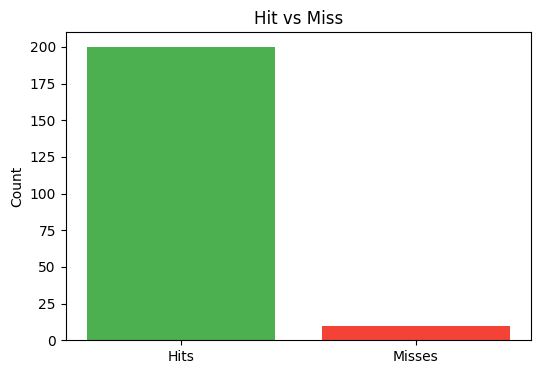

Plot saved to nepali_embedding_model/plot_rank_distribution.png


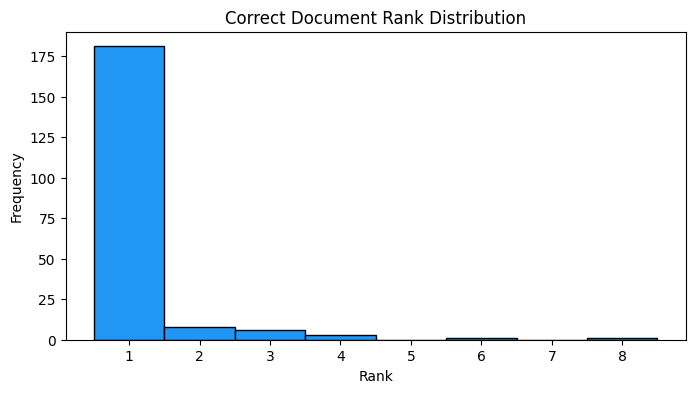

Plot saved to nepali_embedding_model/plot_reciprocal_rank_distribution.png


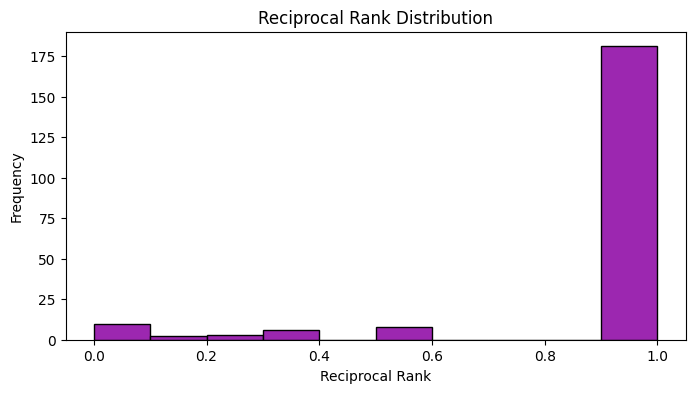

Plot saved to nepali_embedding_model/plot_latency_distribution.png


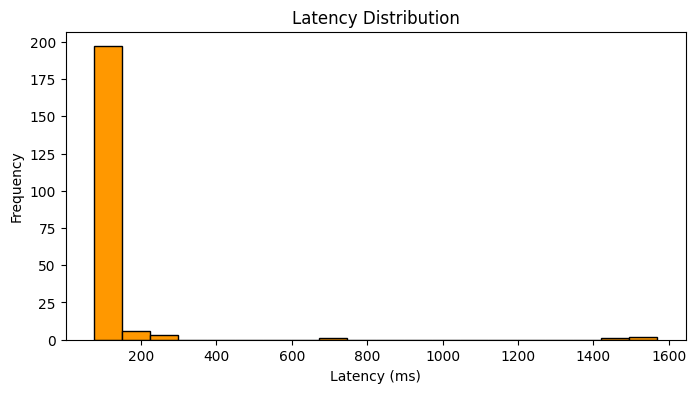

Plot saved to nepali_embedding_model/plot_recall_curve.png


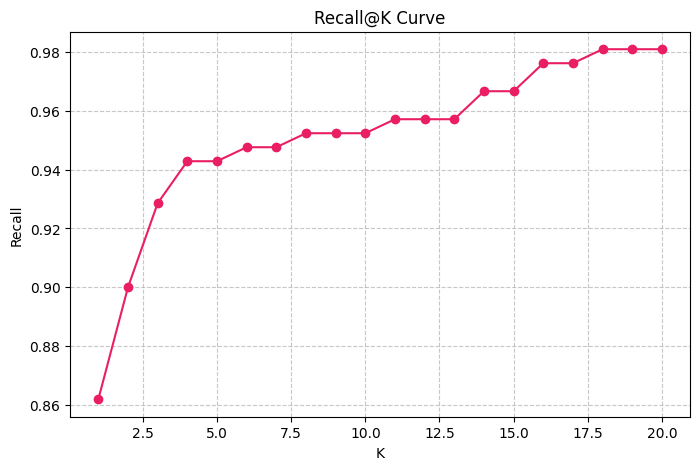

Plot saved to nepali_embedding_model/plot_hit_rate_curve.png


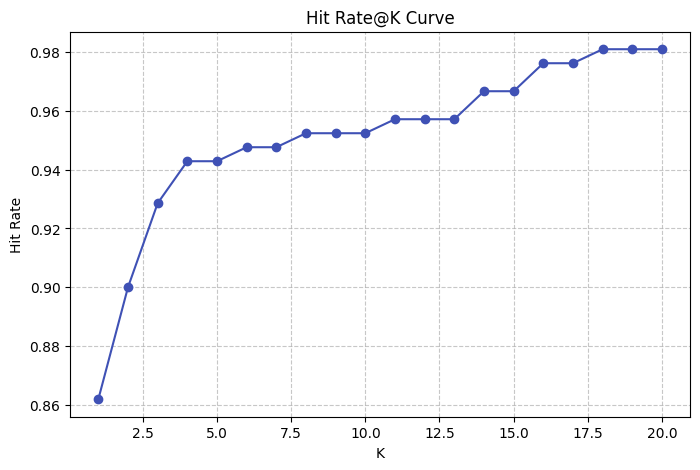

Plot saved to nepali_embedding_model/plot_mrr_curve.png


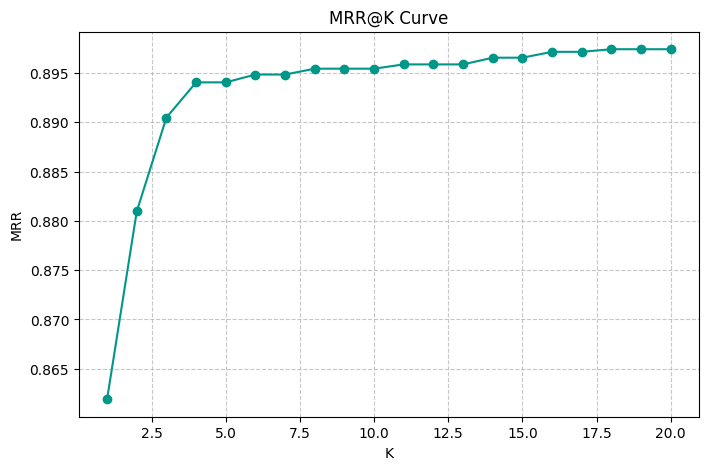

In [12]:
eval_data = load_evaluation_queries(QUERIES_JSON_PATH)

evaluator = RetrievalEvaluator(
    db_manager=db_manager,
    eval_data=eval_data,
    k=10
)

evaluator.evaluate()

evaluator.summary()

evaluator.plot_hit_miss(save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_rank_distribution(save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_reciprocal_rank_distribution(save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_latency_distribution(save_dir=EVALUATION_SAVING_DIR)

evaluator.plot_recall_curve(max_k=20,save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_hit_rate_curve(max_k=20,save_dir=EVALUATION_SAVING_DIR)
evaluator.plot_mrr_curve(max_k=20,save_dir=EVALUATION_SAVING_DIR)

failures = evaluator.failed_queries()

In [13]:
# import os

In [14]:
# def save_results_json(self, filename="evaluation_results_nepali.json"):

#     os.makedirs("evaluation_plots", exist_ok=True)

#     data = [
#         {
#             "query": r.query,
#             "expected_id": r.expected_id,
#             "hit": r.hit,
#             "rank": r.rank,
#             "reciprocal_rank": r.reciprocal_rank,
#             "latency_ms": r.latency_ms,
#         }
#         for r in self.results
#     ]

#     path = os.path.join("evaluation_plots", filename)

#     with open(path, "w") as f:
#         json.dump(data, f, indent=2)

#     print(f"Saved results → {path}")

In [15]:
# save_results_json(evaluator)